--- Sample Customer Data ---
   CustomerID  Age  Annual_Income_k$  Spending_Score Location
0           1   56                84              64     West
1           2   69                86              49     East
2           3   46                41              17    South
3           4   32                23              44    South
4           5   60                76              92    North

--- Segment Counts ---
Customer_Segment
Moderate Spend                           82
Low Income & Low Spend                   64
High Income & High Spend (High Value)    54
Name: count, dtype: int64


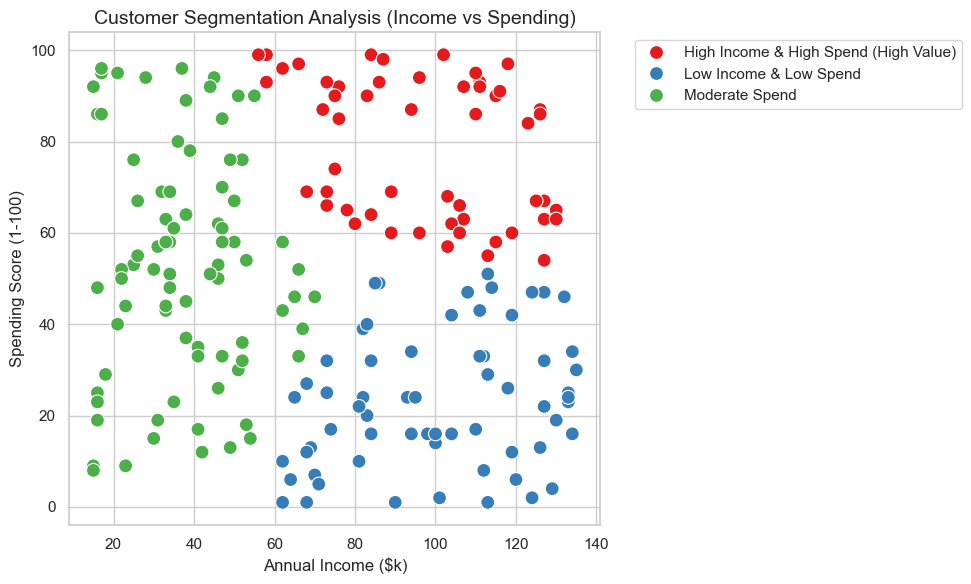


=== 💡 BONUS: Marketing Strategies ===
1. High Value Customers: Provide VIP Loyalty Programs, Exclusive Discounts & Early Product Access.
2. Low Spend Customers: Send Targeted Promotions, Festival Offers & Personalized Recommendations.


In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

np.random.seed(42)
data = {
    'CustomerID': range(1, 201),
    'Age': np.random.randint(18, 70, 200),
    'Annual_Income_k$': np.random.randint(15, 137, 200),
    'Spending_Score': np.random.randint(1, 100, 200),
    'Location': np.random.choice(['North', 'South', 'East', 'West'], 200)
}

df = pd.DataFrame(data)

print("--- Sample Customer Data ---")
print(df.head())

X = df[['Annual_Income_k$', 'Spending_Score']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

cluster_names = {
    0: 'Low Income & Low Spend',
    1: 'High Income & High Spend (High Value)',
    2: 'Moderate Spend'
}
df['Customer_Segment'] = df['Cluster'].map(cluster_names)

print("\n--- Segment Counts ---")
print(df['Customer_Segment'].value_counts())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Annual_Income_k$', 
    y='Spending_Score', 
    hue='Customer_Segment', 
    palette='Set1', 
    s=100
)

plt.title('Customer Segmentation Analysis (Income vs Spending)', fontsize=14)
plt.xlabel('Annual Income ($k)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n=== 💡 BONUS: Marketing Strategies ===")
print("1. High Value Customers: Provide VIP Loyalty Programs, Exclusive Discounts & Early Product Access.")
print("2. Low Spend Customers: Send Targeted Promotions, Festival Offers & Personalized Recommendations.")